# Kalman Filter for Stock Price Estimation

## Objective
Apply a Kalman Filter to estimate the true underlying trend of a noisy stock price series,
and compare it against a simple 20-day Moving Average.

## Approach
- Fetch real AAPL stock data (2023) using `yfinance`
- Model price as a 2-state system: **price** and **velocity**
- Run a Linear Kalman Filter using `filterpy`
- Compare performance against a 20-day Moving Average using MAE, RMSE, and residual std dev

## Results
| Metric | Kalman Filter | Moving Average |
|--------|--------------|----------------|
| MAE    | 1.1832       | 4.8089         |
| RMSE   | 1.5367       | 5.7520         |
| Std Dev| 1.5364       | 5.2825         |

## Connection to Robotics
This is the same math as EKF-based robot state estimation — just applied to financial time series instead of robot pose.

[*********************100%***********************]  1 of 1 completed

Downloaded 250 trading days of AAPL data


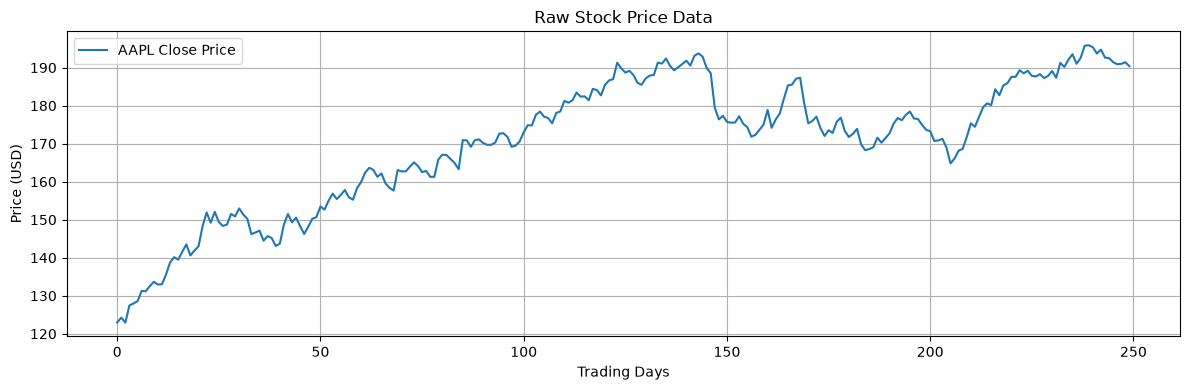

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Fetch stock data
ticker = "AAPL"
data = yf.download(ticker, start="2023-01-01", end="2024-01-01")

# We'll work with the closing price
close_prices = data["Close"].dropna().values.flatten()

print(f"Downloaded {len(close_prices)} trading days of {ticker} data")
plt.figure(figsize=(12, 4))
plt.plot(close_prices, label="AAPL Close Price")
plt.title("Raw Stock Price Data")
plt.xlabel("Trading Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [2]:
from filterpy.kalman import KalmanFilter

def build_kalman_filter(initial_price):
    kf = KalmanFilter(dim_x=2, dim_z=1)

    # State transition matrix — assumes price follows constant velocity model
    kf.F = np.array([[1, 1],
                     [0, 1]])

    # Measurement matrix — we only observe price, not velocity
    kf.H = np.array([[1, 0]])

    # Measurement noise — how much we distrust the raw price
    kf.R = np.array([[5.0]])

    # Process noise — how much the true price can change each step
    kf.Q = np.array([[0.1, 0],
                     [0,   0.1]])

    # Initial state
    kf.x = np.array([[initial_price],
                     [0]])

    # Initial uncertainty
    kf.P = np.eye(2) * 500

    return kf

# Run the filter over all price data
kf = build_kalman_filter(float(close_prices[0]))

filtered = []
for price in close_prices:
    kf.predict()
    kf.update([[price]])
    filtered.append(kf.x[0, 0])

filtered = np.array(filtered)
print("Kalman filter ran successfully.")
print(f"First estimate: {filtered[0]:.2f}, Last estimate: {filtered[-1]:.2f}")

Kalman filter ran successfully.
First estimate: 122.98, Last estimate: 190.40


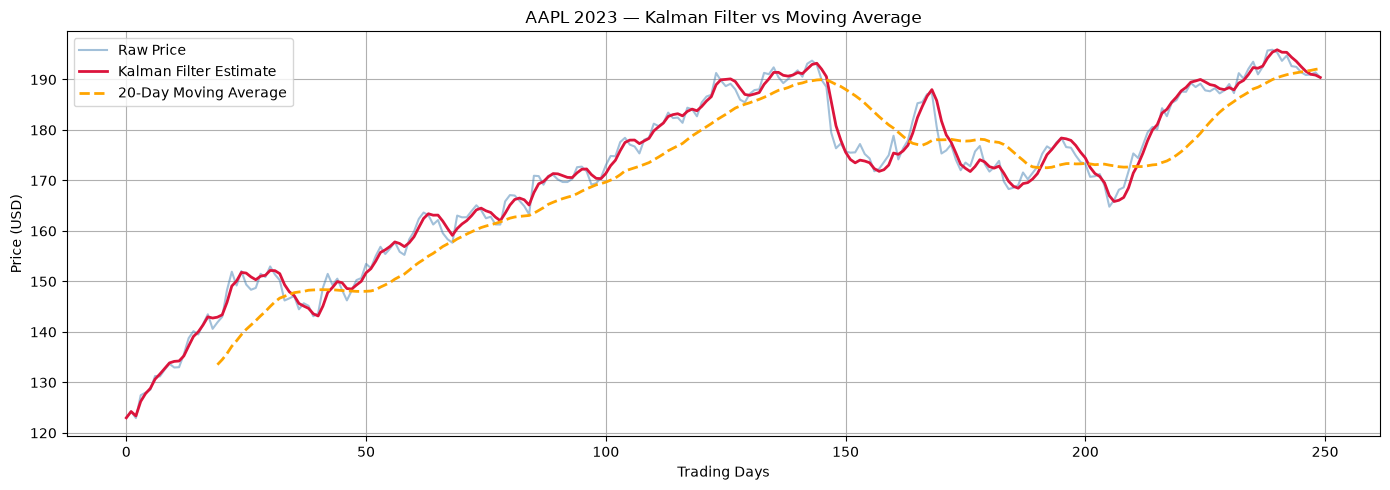

In [3]:
# Simple moving average for comparison
window = 20
moving_avg = pd.Series(close_prices).rolling(window=window).mean().values

# Plot everything together
plt.figure(figsize=(14, 5))
plt.plot(close_prices, label="Raw Price", alpha=0.5, color="steelblue")
plt.plot(filtered, label="Kalman Filter Estimate", color="crimson", linewidth=2)
plt.plot(moving_avg, label=f"{window}-Day Moving Average", color="orange", linewidth=2, linestyle="--")

plt.title("AAPL 2023 — Kalman Filter vs Moving Average")
plt.xlabel("Trading Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
# Lag analysis — how quickly does each method react?
residuals_kalman = close_prices - filtered
residuals_ma = close_prices[window:] - moving_avg[window:]

print("=== Kalman Filter vs Moving Average ===\n")
print(f"Kalman  — MAE: {np.mean(np.abs(residuals_kalman)):.4f}")
print(f"Moving Avg — MAE: {np.mean(np.abs(residuals_ma)):.4f}")

print(f"\nKalman  — RMSE: {np.sqrt(np.mean(residuals_kalman**2)):.4f}")
print(f"Moving Avg — RMSE: {np.sqrt(np.mean(residuals_ma**2)):.4f}")

print(f"\nKalman  — Std Dev of residuals: {np.std(residuals_kalman):.4f}")
print(f"Moving Avg — Std Dev of residuals: {np.std(residuals_ma):.4f}")

=== Kalman Filter vs Moving Average ===

Kalman  — MAE: 1.1832
Moving Avg — MAE: 4.8089

Kalman  — RMSE: 1.5367
Moving Avg — RMSE: 5.7520

Kalman  — Std Dev of residuals: 1.5364
Moving Avg — Std Dev of residuals: 5.2825


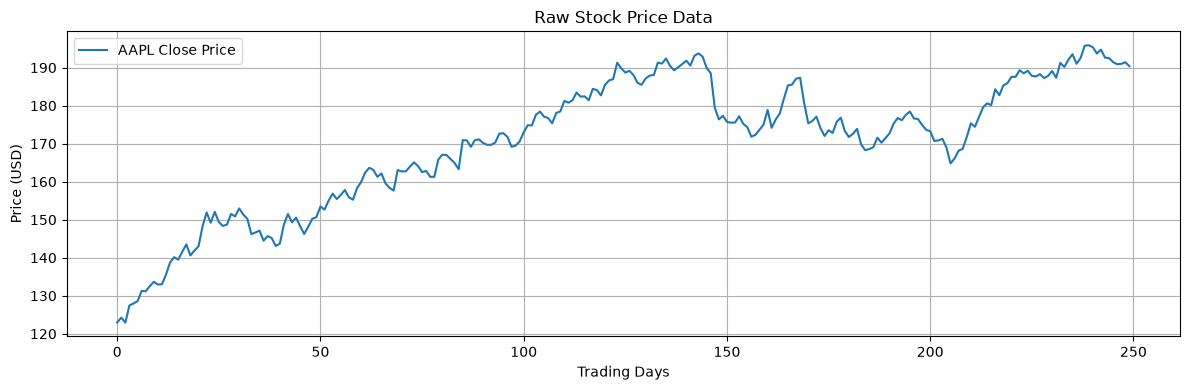

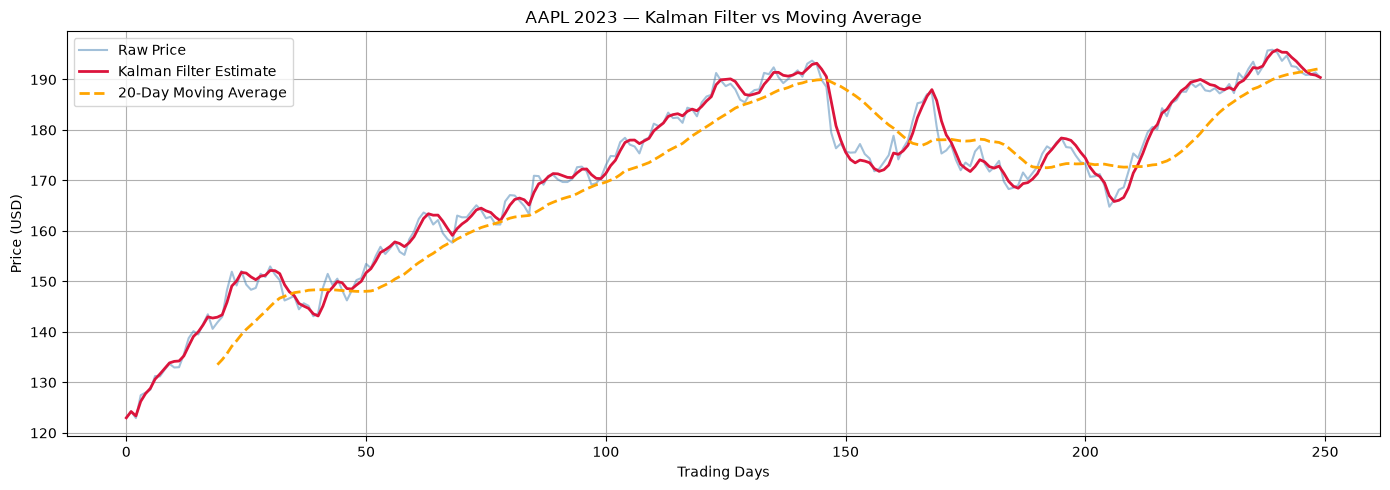

In [5]:
import os
os.makedirs("images", exist_ok=True)

# Save the raw price plot
plt.figure(figsize=(12, 4))
plt.plot(close_prices, label="AAPL Close Price")
plt.title("Raw Stock Price Data")
plt.xlabel("Trading Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("images/raw_price.png", dpi=150)
plt.show()

# Save the comparison plot
plt.figure(figsize=(14, 5))
plt.plot(close_prices, label="Raw Price", alpha=0.5, color="steelblue")
plt.plot(filtered, label="Kalman Filter Estimate", color="crimson", linewidth=2)
plt.plot(moving_avg, label="20-Day Moving Average", color="orange", linewidth=2, linestyle="--")
plt.title("AAPL 2023 — Kalman Filter vs Moving Average")
plt.xlabel("Trading Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("images/kalman_vs_ma.png", dpi=150)
plt.show()

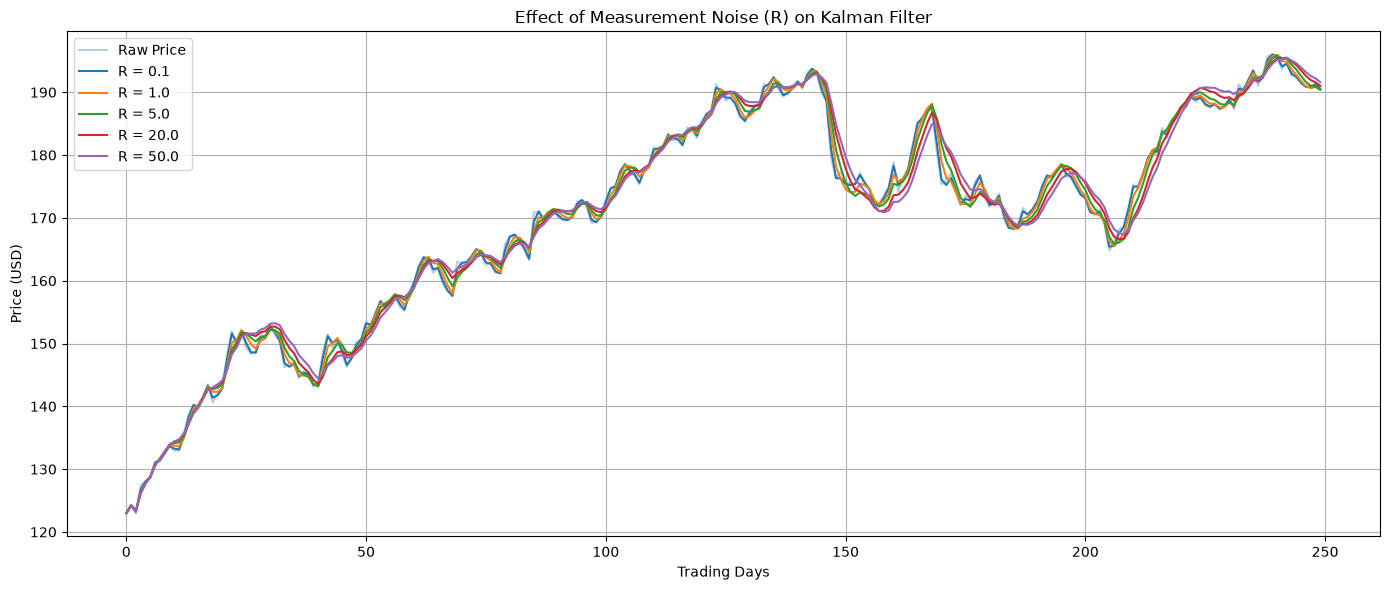

In [6]:
# Sensitivity Analysis — Effect of Measurement Noise (R)
r_values = [0.1, 1.0, 5.0, 20.0, 50.0]
plt.figure(figsize=(14, 6))
plt.plot(close_prices, label="Raw Price", alpha=0.4, color="steelblue")

for r in r_values:
    kf_r = build_kalman_filter(float(close_prices[0]))
    kf_r.R = np.array([[r]])
    filtered_r = []
    for price in close_prices:
        kf_r.predict()
        kf_r.update([[price]])
        filtered_r.append(kf_r.x[0, 0])
    plt.plot(filtered_r, label=f"R = {r}", linewidth=1.5)

plt.title("Effect of Measurement Noise (R) on Kalman Filter")
plt.xlabel("Trading Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("images/sensitivity_R.png", dpi=150)
plt.show()

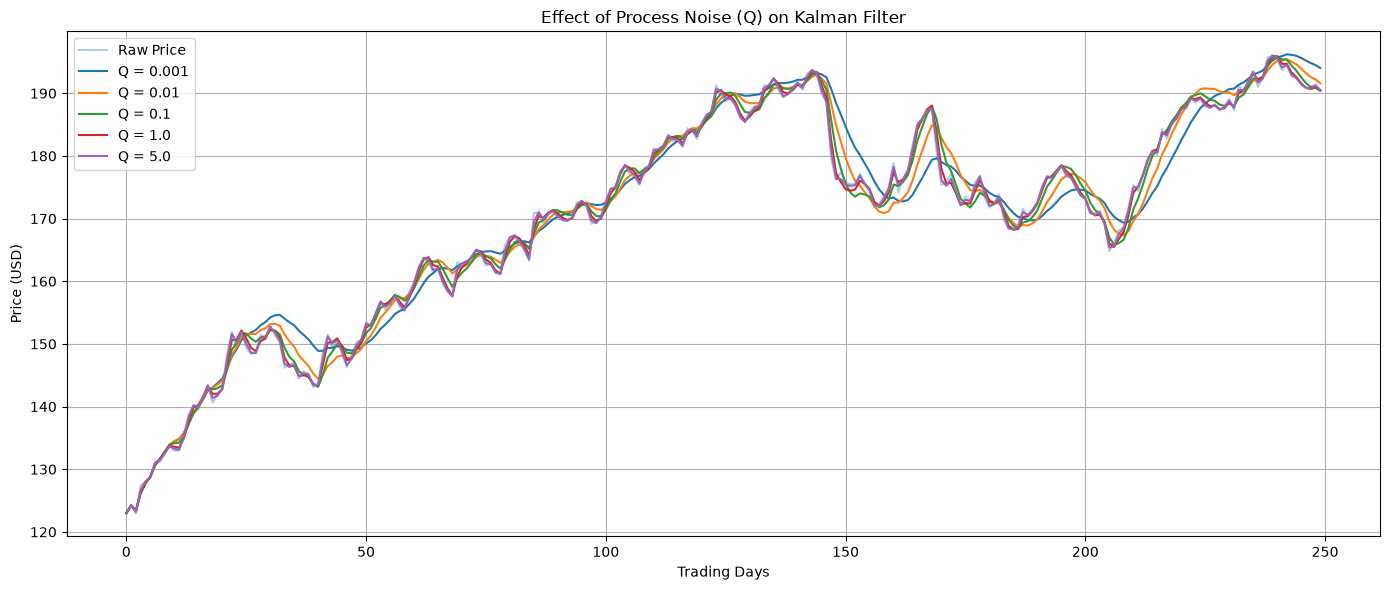

In [7]:
# Sensitivity Analysis — Effect of Process Noise (Q)
q_values = [0.001, 0.01, 0.1, 1.0, 5.0]
plt.figure(figsize=(14, 6))
plt.plot(close_prices, label="Raw Price", alpha=0.4, color="steelblue")

for q in q_values:
    kf_q = build_kalman_filter(float(close_prices[0]))
    kf_q.Q = np.array([[q, 0],
                        [0, q]])
    filtered_q = []
    for price in close_prices:
        kf_q.predict()
        kf_q.update([[price]])
        filtered_q.append(kf_q.x[0, 0])
    plt.plot(filtered_q, label=f"Q = {q}", linewidth=1.5)

plt.title("Effect of Process Noise (Q) on Kalman Filter")
plt.xlabel("Trading Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("images/sensitivity_Q.png", dpi=150)
plt.show()